Copyright (c) 2025 Mitsuru Ohno  
Use of this source code is governed by a BSD-3-style  
license that can be found in the LICENSE file.  

## 当ノートブックのワークフロー  
速度定数を時間の関数として表現する場合の事例。  
1. 未知の速度定数を含む、csvに書き込んだ反応式を読み込む。  
2. 化学種の濃度の経時変化の実験データを読み込む。実験データには欠損を含んでもよい。  
2. RxnIVPsolv("sample_data.csv")でインスタンス化し、化学種ごとの微分型の反応速度式を作成する。速度定数が未知の素反応にはシンボリックな変数が割り振られる。  
3. 作成した微分方程式を、数値解析可能な形式にする  
4.  scipy.optimize.minimizeを使い、化学種ごとの濃度の経時変化が、実験値と近づくように、未知の速度定数を求める： get_ode_system()で必要なオブジェクトを取得。  
5. 経時変化を図示する： matplotlibで結果をプロット  

もしエラーが発生した場合は、debug_ode_system()メソッドで詳細な情報を確認できる。  


## 引用文献  
6) Kinetics of Polyesterification: A Study of the Effects of Molecular Weight and Viscosity on Reaction Rate
Paul J. Flory, Journal of the American Chemical Society 1939 61 (12), 3334-3340, DOI: 10.1021/ja01267a030  
https://doi.org/10.1021/ja01267a030  

### 事前のデータ処理  
Table Iのデータに以下の処理を施した。内容はref6.xlsxを参照のこと。  
- diethylene glycol (DEG: MW 106.12), adipic acid (AdA: MW 146.14)とした。CRUのMWは 106.12 + 146.12 - 18.02 x 2 = 216.22とした。  
- 初期濃度t = 0は、モノマーであるDEGとAdAが、1,000 g 中に等物質量ずつ含まれているとした。ともに3.964 molずつで、 DEG (420.7 g)、AdA (579.3 g) になる。  
- polyesterのDPnからMnを算出した。DPn=0の場合を除き、Mn = DPn x 216.22 + 18.02 とした。  
- 触媒の重量は無視できるとした。  
- 各反応時間でのモノマー残量は表中のρ（転嫁率に相当）から算出した。  
- 発生した水は速やかに系から除去されるとし、その重量をρから算出した。t=0での総重量 1,000 gから、発生した水の重量を減じ、各時間での総重量を求めた。  
- DEG, AdA以外はすべてpolyesterと考えてその重量を算出し、各時間でのMnで除して主鎖の物質量とした。  
- 各時間での、各化学種の物質量を、その時点での総重量/1000 で除し、濃度 \[mol/1000g\] とした。  

計算の詳細は './sample_data/ref6/sample_rxn_ref6.xlsx' を参照。


## <span style="color: red; font-weight: bold;">under preparaion</span>
### 考え方  
解析はMnの成長速度を見込むことを目標にした。ただし、数値のオーダーを、化学種の濃度のそれと揃えるため、Mnを1000で除した値（mMn: ミリMn）を用いた。  

**主鎖成長の速度定数**  
主鎖の成長の速度定数kpは、モノマー同士の速度定数kmに対する時間の関数として表現でき、ある時間でのkpは  

$kp = {a}{k_m}{exp({-b}{t})}$ (eq 1)  

で表されると仮定した。  
重合初期では反応速度はモノマー濃度に支配され、重合の進行に伴う粘度上昇や分子量増大により拡散係数および実効的な頻度因子が低下する。この効果を、反応速度定数 k の時間依存的変化として表現する考え方である。  
よって、フィッティングでは、kmとaを求めることとなる。  
この際、モノマー同士の反応により "olg" （オリゴマー）が生成し、olg同志の反応によりポリマーが生成する、と素反応を設定した。すなわち、モノマーが主鎖末端に縮合して主鎖成長するパスは無視しており、かつオリゴマーの反応性は鎖長によらず同一と暗に仮定していることになる。なお、olg濃度はt=0で0、他は全て未知（空欄）とした。  

**目的変数**  
目的変数は、数平均分子量そのものではなく、反応液単位重量中の、重合により新たに生成した、CRU間の結合の濃度とし、これと数平均分子量の理論的は関係を表す式を算出した。  

Carothers equationと同様の考え方により、本系での数平均分子量Mnは、

$DP_n = \frac{1}{(1 - p)^2} = \frac{M_n - M_T}{M_{\mathrm{CRU}}} = \frac{[mon]_0}{[polym]}$ (eq 2)  

ただし $M_{\mathrm{CRU}}$ は CRU の、$M_T$は両末端封止基の分子量、$[mon]_0$ は初期基準モノマー濃度、$[polm]$ はポリマー濃度である。    

また、CRUの新たな重合により形成された結合の数を $N_{\mathrm{fB}}$ とすると、  

$N_{\mathrm{fB}} = DP_n - 1$ (eq3)  

となる。また、eq2 から、  

$[polym] = \frac{{[mon]_0}{M_{\mathrm{CRU}}}}{M_n - M_T}$ (eq4)  

となる。さらに、  

$C_{\mathrm{fB}} = {[polym]}{N_{\mathrm{fB}}} = {[polym]}{(DP_n - 1)}$ (eq5)

となる。したがって、eq5, eq4, eq2 から、  

$C_{\mathrm{fB}} = {\frac{{[mon]_0}{M_{\mathrm{CRU}}}}{M_n - M_T}}{({\frac{M_n - M_T}{M_{\mathrm{CRU}}}} - 1)} = {[mon]_0}{(1 - {\frac{M_{\mathrm{CRU}}}{M_n - M_T}})} = \frac{{[mon]_0}{(M_n - (M_{\mathrm{CRU}} + M_T))}}{M_n - M_T}$ (eq6)  

となる。よって、分析値 $M_n$ が判れば、 $C_{\mathrm{fB}}$ を求めることができる（ただし末端慚愧の分子量 $M_T$ は、一義的なものともいえず、将来的にはフィッティング対象としたい）。なお、    

$M_n = \frac{{[mon]_0}{M_{\mathrm{CRU}}}}{[mon]_0 - C_{\mathrm{fB}}} + M_T$ (eq7)    

である。  



## 反応式, 速度定数の定義を記載したcsvファイルを指定する  

In [ ]:
# tempolary added for development on local machine
# import sys, os

# project_root = os.getcwd()  # Notebook を開いたディレクトリ
# sys.path.append(os.path.join(project_root, "../src"))

In [2]:
file_path_rxn = './sample_data/ref6/sample_rxn_ref6.csv'  # CSVファイルのパスを指定
file_path_k = './sample_data/ref6/sample_k_ref6.csv'

## 反応速度式をscipy.integrate.solve_ivpで処理できる連立微分方程式にする  

In [3]:
import time

import numpy as np
import pandas as pd

from rxnfit import RxnODEbuild, SolverConfig, RxnODEsolver
from rxnfit.expdata_reader import expdata_read
from rxnfit.expdata_fit import ExpDataFit
from rxnfit.p0_opt_fit import P0OptFit

/home/mt_oh/work/rxnfit/venv312u/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 反応速度式の作成

In [4]:
builded_rxnode = RxnODEbuild(
    file_path_rxn, 
    rate_const_overrides=file_path_k) # 時間の関数で表現される速度定数の定義場所を指定  

In [5]:
builded_rxnode.get_ode_info(debug_info=True)

number of species: 4
unique species: ['DEG', 'AdA', 'olg', 'CfB']
rate constant: {'km': km, 'kp': km*exp(-a*t)}

=== debug info ===
Successfully created function for DEG with args: ['t', 'DEG', 'AdA', 'olg', 'CfB']
Successfully created function for AdA with args: ['t', 'DEG', 'AdA', 'olg', 'CfB']
Successfully created function for olg with args: ['t', 'DEG', 'AdA', 'olg', 'CfB']
Successfully created function for CfB with args: ['t', 'DEG', 'AdA', 'olg', 'CfB']
order of args: ['t', 'DEG', 'AdA', 'olg', 'CfB']
system of ODE: {'DEG': '-1/1*km*DEG(t)*AdA(t)', 'AdA': '-1/1*km*DEG(t)*AdA(t)', 'olg': '1/1*km*DEG(t)*AdA(t)-1/1*kp*olg(t)*olg(t)-1/1*kp*olg(t)*olg(t)', 'CfB': '1/1*kp*olg(t)*olg(t)'}


In [6]:
# 作成した微分方程式
builded_rxnode.get_ode_system()[0]

Successfully created function for DEG with args: ['t', 'DEG', 'AdA', 'olg', 'CfB']
Successfully created function for AdA with args: ['t', 'DEG', 'AdA', 'olg', 'CfB']
Successfully created function for olg with args: ['t', 'DEG', 'AdA', 'olg', 'CfB']
Successfully created function for CfB with args: ['t', 'DEG', 'AdA', 'olg', 'CfB']


[Eq(Derivative(DEG(t), t), -km*AdA(t)*DEG(t)),
 Eq(Derivative(AdA(t), t), -km*AdA(t)*DEG(t)),
 Eq(Derivative(olg(t), t), km*AdA(t)*DEG(t) - 2*km*olg(t)**2*exp(-a*t)),
 Eq(Derivative(CfB(t), t), km*olg(t)**2*exp(-a*t))]

In [7]:
# 速度定数の確認
print(builded_rxnode.rate_consts_dict)

check_type = [v for v in builded_rxnode.rate_consts_dict.values()]
[type(e) for e in check_type]

{'km': km, 'kp': km*exp(-a*t)}


[sympy.core.symbol.Symbol, sympy.core.mul.Mul]

## 経時変化の実験データを読み込み　　
### データフレーム化  

In [8]:
file_path_data = './sample_data/ref6/sample_timecourse_ref6.csv' # データファイルのパス
df1 = pd.read_csv(file_path_data)

expdata_read([df1,])

[([array([   0,    6,   12,   23,   37,   59,   88,  129,  170,  203,  235,
           270,  321,  397,  488,  596,  690,  793,  900, 1008, 1147, 1370,
          1606]),
   array([   0,    6,   12,   23,   37,   59,   88,  129,  170,  203,  235,
           270,  321,  397,  488,  596,  690,  793,  900, 1008, 1147, 1370,
          1606]),
   array([0]),
   array([   0,    6,   12,   23,   37,   59,   88,  129,  170,  203,  235,
           270,  321,  397,  488,  596,  690,  793,  900, 1008, 1147, 1370,
          1606])],
  [array([3.96416396, 3.45150578, 3.03862982, 2.574931  , 2.06539344,
          1.62450792, 1.30685295, 1.04179943, 0.8847438 , 0.77414017,
          0.69599279, 0.63306365, 0.56120646, 0.49209657, 0.43458215,
          0.38831555, 0.35503971, 0.3310056 , 0.30863928, 0.29597106,
          0.27442174, 0.25285558, 0.23508256]),
   array([3.96416396, 3.45150578, 3.03862982, 2.574931  , 2.06539344,
          1.62450792, 1.30685295, 1.04179943, 0.8847438 , 0.77414017,
      

### フィッティング  
ExpDataFit でシンボリックな速度定数をフィッティング。  


In [9]:
t_cpu_start = time.process_time() # CPU時間計測

# P0OptFit: RxnODEbuild インスタンスと df_list を渡す（他は最小限）
opt = P0OptFit(builded_rxnode, [df1,], seed=42)
result_dict, fit_metrics = opt.optimize(n_trials=5)

# プロット用に最適 p0 で ExpDataFit を1回実行し、config を取得
keys = builded_rxnode.get_symbolic_rate_const_keys()
p0_best = [result_dict[k][1] for k in keys]
t_range = (0, float(df1.iloc[:, 0].max()))
fit_sci = ExpDataFit(builded_rxnode, [df1, ], t_range)
fit_sci.run_fit(p0_best, use_log_fit=True, lower_bound=1e-10)

t_cpu_end = time.process_time()
elapsed = t_cpu_end - t_cpu_start
h, r = divmod(int(elapsed), 3600)
m, s = divmod(r, 60)
print(f"CPU time: {h:02d}:{m:02d}:{s:02d}")

[I 2026-05-04 21:49:24,274] A new study created in memory with name: no-name-17642612-65cd-4639-8a6c-094beeb50d14
  0%|          | 0/5 [00:00<?, ?it/s]

Successfully created function for DEG with args: ['t', 'DEG', 'AdA', 'olg', 'CfB']
Successfully created function for AdA with args: ['t', 'DEG', 'AdA', 'olg', 'CfB']
Successfully created function for olg with args: ['t', 'DEG', 'AdA', 'olg', 'CfB']
Successfully created function for CfB with args: ['t', 'DEG', 'AdA', 'olg', 'CfB']


Best trial: 0. Best value: 62.5741:  20%|██        | 1/5 [00:09<00:36,  9.05s/it]

[I 2026-05-04 21:49:33,335] Trial 0 finished with value: 62.574080880643756 and parameters: {'a': 5.5641802254313645e-05, 'km': 32.14719348281703}. Best is trial 0 with value: 62.574080880643756.
Successfully created function for DEG with args: ['t', 'DEG', 'AdA', 'olg', 'CfB']
Successfully created function for AdA with args: ['t', 'DEG', 'AdA', 'olg', 'CfB']
Successfully created function for olg with args: ['t', 'DEG', 'AdA', 'olg', 'CfB']
Successfully created function for CfB with args: ['t', 'DEG', 'AdA', 'olg', 'CfB']


Best trial: 1. Best value: 62.5741:  40%|████      | 2/5 [00:14<00:19,  6.65s/it]

...

[I 2026-05-04 21:49:47,830] Trial 2 finished with value: 62.57408088064373 and parameters: {'a': 3.6323392569431376e-07, 'km': 3.6303224667798554e-07}. Best is trial 1 with value: 62.57408088064187.
Successfully created function for DEG with args: ['t', 'DEG', 'AdA', 'olg', 'CfB']
Successfully created function for AdA with args: ['t', 'DEG', 'AdA', 'olg', 'CfB']
Successfully created function for olg with args: ['t', 'DEG', 'AdA', 'olg', 'CfB']
Successfully created function for CfB with args: ['t', 'DEG', 'AdA', 'olg', 'CfB']


Best trial: 1. Best value: 62.5741:  80%|████████  | 4/5 [00:31<00:07,  7.99s/it]

[I 2026-05-04 21:49:55,870] Trial 3 finished with value: 62.57408088064217 and parameters: {'a': 3.809220577048033e-08, 'km': 4.589458612326471}. Best is trial 1 with value: 62.57408088064187.
Successfully created function for DEG with args: ['t', 'DEG', 'AdA', 'olg', 'CfB']
Successfully created function for AdA with args: ['t', 'DEG', 'AdA', 'olg', 'CfB']
Successfully created function for olg with args: ['t', 'DEG', 'AdA', 'olg', 'CfB']
Successfully created function for CfB with args: ['t', 'DEG', 'AdA', 'olg', 'CfB']


Best trial: 1. Best value: 62.5741: 100%|██████████| 5/5 [00:36<00:00,  7.22s/it]


[I 2026-05-04 21:50:00,364] Trial 4 finished with value: 62.574080880642796 and parameters: {'a': 0.010260065124896791, 'km': 0.12042752972516801}. Best is trial 1 with value: 62.57408088064187.
Successfully created function for DEG with args: ['t', 'DEG', 'AdA', 'olg', 'CfB']
Successfully created function for AdA with args: ['t', 'DEG', 'AdA', 'olg', 'CfB']
Successfully created function for olg with args: ['t', 'DEG', 'AdA', 'olg', 'CfB']
Successfully created function for CfB with args: ['t', 'DEG', 'AdA', 'olg', 'CfB']
Optimization success: True
Fitted rate constants:
  a = 1e-08
  km = 0.012936
Residual sum of squares: 62.5741  R²: 0.242035
Successfully created function for DEG with args: ['t', 'DEG', 'AdA', 'olg', 'CfB']
Successfully created function for AdA with args: ['t', 'DEG', 'AdA', 'olg', 'CfB']
Successfully created function for olg with args: ['t', 'DEG', 'AdA', 'olg', 'CfB']
Successfully created function for CfB with args: ['t', 'DEG', 'AdA', 'olg', 'CfB']
Optimization suc


=== Time-course plot ===


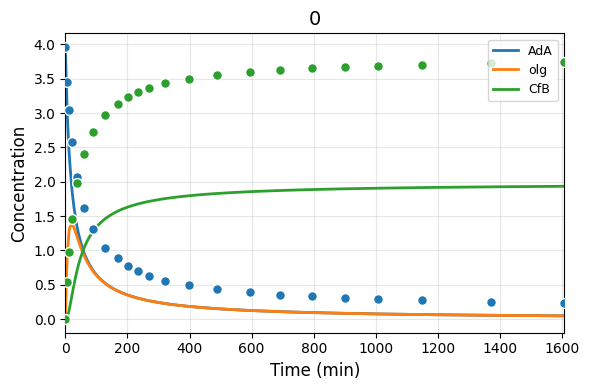


=== Concentration at the final time point ===
0:
  AdA: 0.047557
  olg: 0.047558
  CfB: 1.934524


In [10]:
# 経時変化を図示（plot_fitted_solution を使用）
fit_sci.plot_fitted_solution(expdata_df=df1, species=['AdA', 'olg', 'CfB'])

### 初期値最適化のログの確認  

In [11]:
logs = opt.optuna_log()

rows = []
for d in logs:
    row = {"trial_No": d["trial_No"], "rss": d["rss"], "state": d["state"]}
    row.update(d["params"])
    rows.append(row)
df_log = pd.DataFrame(rows)
df_log

,trial_No,rss,state,a,km
0,1,62.574081,COMPLETE,5.564180e-05,3.214719e+01
1,2,62.574081,COMPLETE,2.089005e-01,9.695827e-03
2,3,62.574081,COMPLETE,3.632339e-07,3.630322e-07
3,4,62.574081,COMPLETE,3.809221e-08,4.589459e+00
4,5,62.574081,COMPLETE,1.026007e-02,1.204275e-01
